In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Customer-Churn.csv')

print(df.shape)           # (7043, 21)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

# Checking class imbalance

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


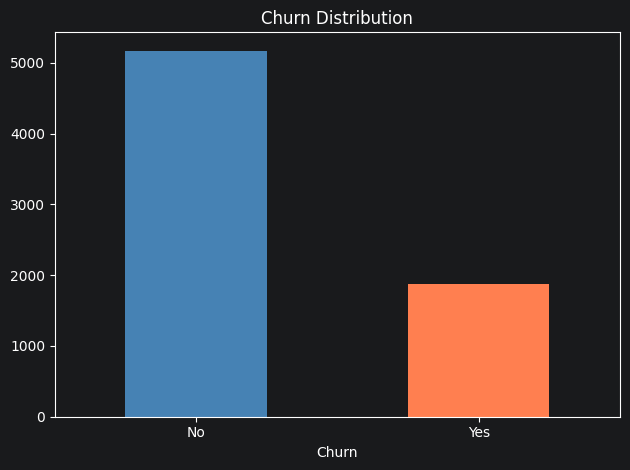

In [3]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

df['Churn'].value_counts().plot(kind='bar', color=['steelblue','coral'])
plt.title('Churn Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Churn by key features


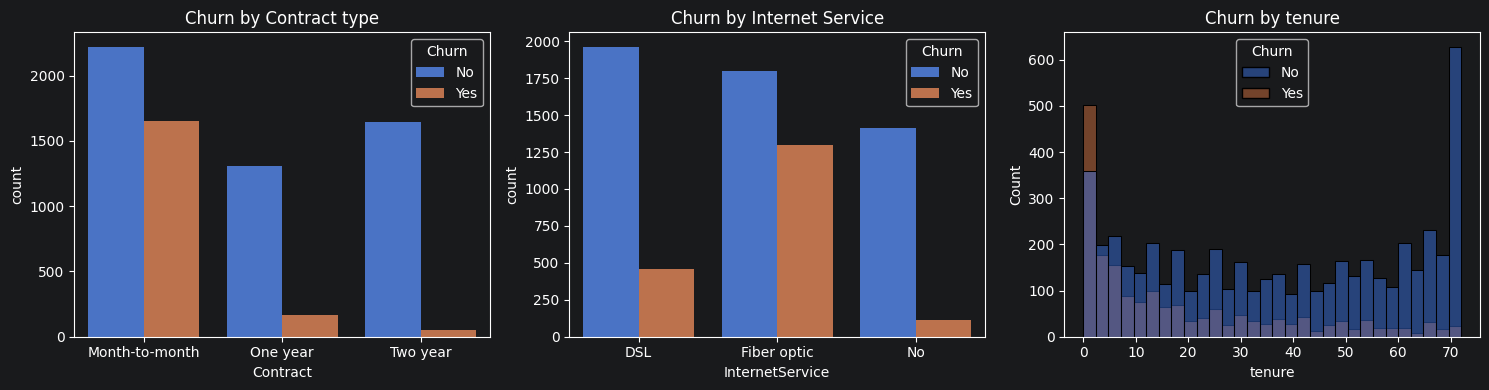

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x='Contract', hue = 'Churn', ax= axes[0])
axes[0].set_title('Churn by Contract type')

sns.countplot(data=df, x="InternetService", hue='Churn', ax= axes[1])
axes[1].set_title('Churn by Internet Service')

sns.histplot(data=df, x='tenure', hue='Churn', bins=30, ax=axes[2])
axes[2].set_title("Churn by tenure")

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

# Correlation heatmap

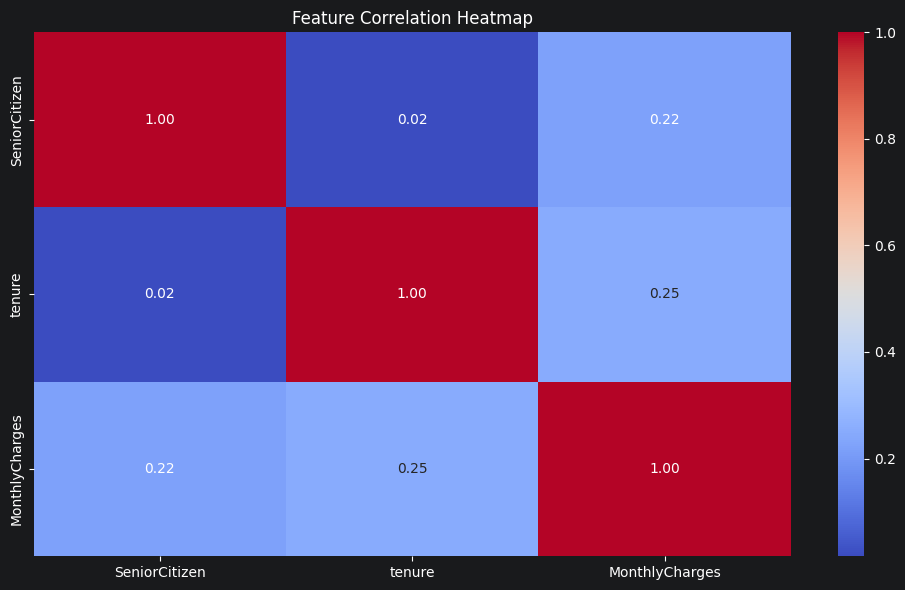

In [5]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize= (10, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

# Fixing Data Types

In [6]:
df = df.drop('customerID', axis=1)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df['Churn'] = (df["Churn"] == 'Yes').astype(int)

print(df.dtypes)
print(df.isnull().sum())


gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn   

# Encoding categorical columns

In [7]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.shape)
print(df_encoded.head())

(7043, 31)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                   

# Splitting the data

In [8]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (5634, 30), Test: (1409, 30)


# Handling class imbalance with smote

In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")


Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}


# Training random forest

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 10,
    random_state = 42,
    class_weight = 'balanced',
)
rf_model.fit(X_train_sm, y_train_sm)
print("Random Forest trained!")



Random Forest trained!


# Training logistic regression to compare

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter= 1000, random_state=42)
lr_model.fit(X_train_scaled, y_train_sm)
print("Logistic Regression trained!")


Logistic Regression trained!


# Saving the model feature names

In [14]:
import pickle

with open('model/model.pkl', 'wb',) as f:
    pickle.dump(rf_model, f)

with open('model/feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("Model Saved!")

Model Saved!


# Classification report

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_rf = rf_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test_scaled)

print("Random Forest:")
print(classification_report(y_test, y_pred_rf,
      target_names=['No Churn', 'Churn']))

print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr,
      target_names=['No Churn', 'Churn']))


Random Forest:
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.54      0.69      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409

Logistic Regression:
              precision    recall  f1-score   support

    No Churn       0.86      0.81      0.83      1035
       Churn       0.54      0.63      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.76      0.77      1409



# Confusion matrix

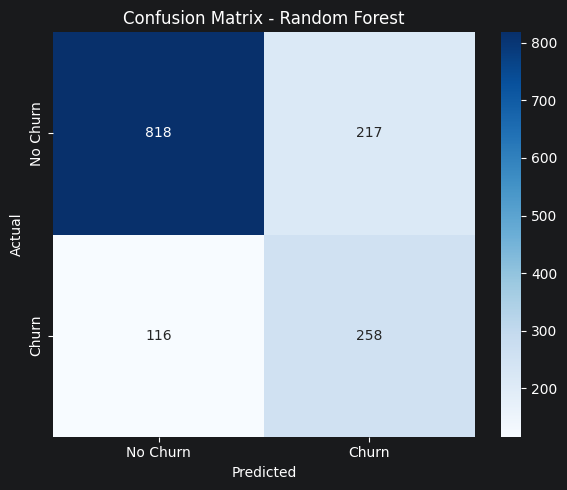

In [16]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize= (6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels= ['No Churn', 'Churn'],
            yticklabels= ['No Churn', 'Churn'])

plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Feature importance chart

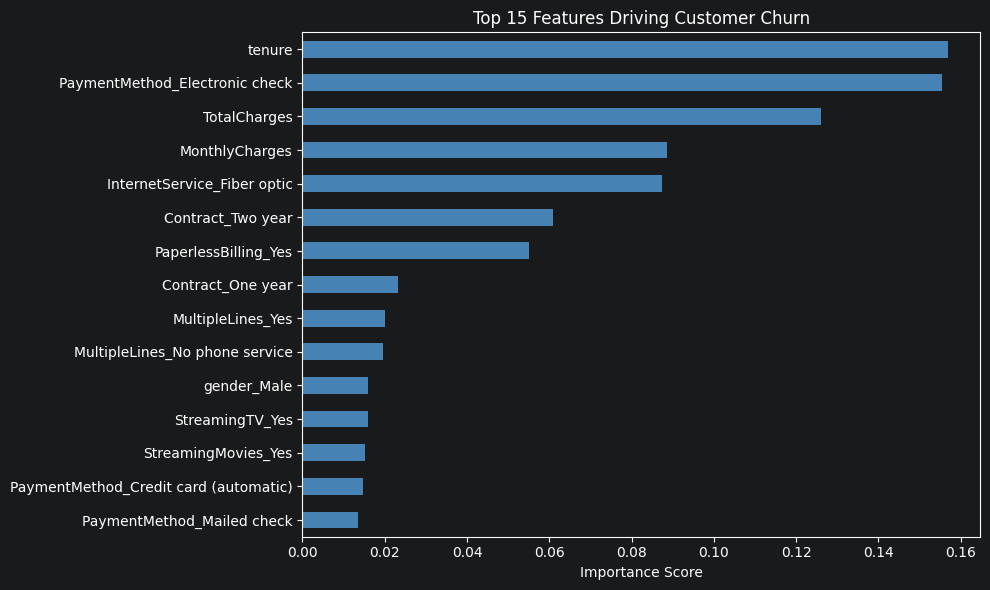

In [17]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)[:15]

plt.figure(figsize= (10, 6))
importances.plot(kind="barh", color= 'steelblue')
plt.title('Top 15 Features Driving Customer Churn')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# ROC - AUC SCORE

In [18]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_rf)
print(f"ROC AUC SCORE: {auc:.4f}")


ROC AUC SCORE: 0.8332
